# 🎬 Netflix Recommendation System

# Notebook 4: Model Training & Evaluation

## Author
Bishal Gurung

## Objective

This notebook focuses on training and evaluating different machine learning models to classify Netflix content into Movies and TV Shows.

### Models Used

- Baseline Model
- Logistic Regression
- Naive Bayes
- Decision Tree
- Hyperparameter Tuning
- K-Nearest Neighbors (KNN)

Finally, we compare the performance of all models and save the trained models for deployment.

# Import Required Libraries

In [69]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# Load Cleaned Dataset

In [70]:
df = pd.read_csv("../data/processed/netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


# Feature Engineering

We combine title, genre, and description into one text column. This gives the ML model more information.

In [71]:
df["text"] = (
    df["title"].astype(str)
    + " "
    + df["listed_in"].astype(str)
    + " "
    + df["description"].astype(str)
)

# Convert target labels into numbers
# Movie = 0, TV Show = 1

df["target"] = df["type"].map({
    "Movie": 0,
    "TV Show": 1
})

df[["type", "target", "text"]].head()

,type,target,text
0,Movie,0,Dick Johnson Is Dead Documentaries As her fath...
1,TV Show,1,"Blood & Water International TV Shows, TV Drama..."
2,TV Show,1,"Ganglands Crime TV Shows, International TV Sho..."
3,TV Show,1,"Jailbirds New Orleans Docuseries, Reality TV F..."
4,TV Show,1,"Kota Factory International TV Shows, Romantic ..."


# Train-Test Split
We split data into training and testing sets. This helps us check whether the model performs well on unseen data.

In [72]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (7045,)
Testing size: (1762,)


# TF-IDF Vectorization
Machine learning models cannot understand raw text. TF-IDF converts text into numerical features.

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (7045, 5000)
Test TF-IDF shape: (1762, 5000)


# Baseline Model

A baseline model gives us a minimum score to beat. Here, the baseline always predicts the most common class.

In [74]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_tfidf, y_train)
baseline_pred = baseline.predict(X_test_tfidf)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.6963677639046538


# Logistic Regression
Logistic Regression is a strong and simple model for classification tasks.

In [75]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_pred)
lr_probs = lr.predict_proba(X_test_tfidf)[:, 1]
lr_roc_auc = roc_auc_score(y_test, lr_probs)

print("Logistic Regression Accuracy:", lr_acc)
print("ROC AUC:", lr_roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9903518728717366
ROC AUC: 0.9998171971756964

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1227
           1       1.00      0.97      0.98       535

    accuracy                           0.99      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       0.99      0.99      0.99      1762



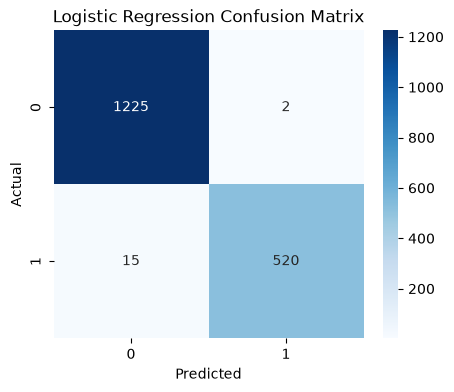

In [76]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Naive Bayes

Naive Bayes works very well for text classification because it is based on word probabilities.

In [77]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, nb_pred)
nb_probs = nb.predict_proba(X_test_tfidf)[:, 1]
nb_roc_auc = roc_auc_score(y_test, nb_probs)

print("Naive Bayes Accuracy:", nb_acc)
print("ROC AUC:", nb_roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.963677639046538
ROC AUC: 0.9961535239052777

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1227
           1       0.99      0.89      0.94       535

    accuracy                           0.96      1762
   macro avg       0.97      0.94      0.96      1762
weighted avg       0.97      0.96      0.96      1762



# Decision Tree

Decision Tree learns simple decision rules from the TF-IDF features.

In [78]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tfidf, y_train)
dt_pred = dt.predict(X_test_tfidf)

dt_acc = accuracy_score(y_test, dt_pred)
dt_probs = dt.predict_proba(X_test_tfidf)[:, 1]
dt_roc_auc = roc_auc_score(y_test, dt_probs)

print("Decision Tree Accuracy:", dt_acc)
print("ROC AUC:", dt_roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9914869466515324
ROC AUC: 0.9907250417018942

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1227
           1       0.98      0.99      0.99       535

    accuracy                           0.99      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       0.99      0.99      0.99      1762



# Hyperparameter Tuning for Decision Tree

We tune `max_depth` to find the best tree depth. This helps avoid overfitting and underfitting.

In [79]:
depth_results = []

for depth in range(1, 31):
    dt_tuned = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    dt_tuned.fit(X_train_tfidf, y_train)
    pred = dt_tuned.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    
    depth_results.append({
        "max_depth": depth,
        "accuracy": acc
    })

depth_df = pd.DataFrame(depth_results)
depth_df.sort_values(by="accuracy", ascending=False).head()

,max_depth,accuracy
1,2,0.996027
2,3,0.994892
3,4,0.994892
7,8,0.994892
6,7,0.994325


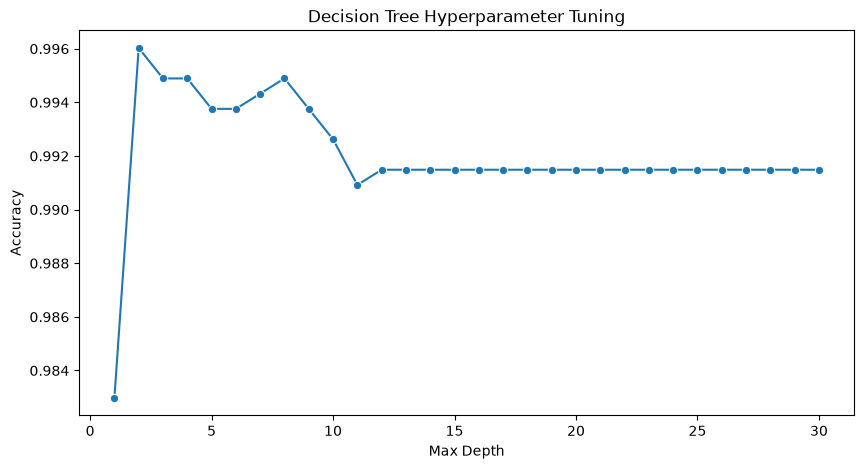

In [80]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=depth_df, x="max_depth", y="accuracy", marker="o")
plt.title("Decision Tree Hyperparameter Tuning")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.show()

In [81]:
best_depth = int(depth_df.sort_values(by="accuracy", ascending=False).iloc[0]["max_depth"])

dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_best.fit(X_train_tfidf, y_train)
dt_best_pred = dt_best.predict(X_test_tfidf)
dt_best_acc = accuracy_score(y_test, dt_best_pred)

print("Best max_depth:", best_depth)
print("Tuned Decision Tree Accuracy:", dt_best_acc)
print(classification_report(y_test, dt_best_pred))

Best max_depth: 2
Tuned Decision Tree Accuracy: 0.9960272417707151
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       0.99      1.00      0.99       535

    accuracy                           1.00      1762
   macro avg       0.99      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



# KNN Classifier

KNN predicts the class by looking at the nearest examples. We test different values of K.

In [82]:
from sklearn.neighbors import KNeighborsClassifier

k_results = []

for k in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_tfidf, y_train)
    pred = knn.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    
    k_results.append({
        "K": k,
        "Accuracy": acc
    })

k_df = pd.DataFrame(k_results)
k_df.sort_values(by="Accuracy", ascending=False).head()

,K,Accuracy
24,25,0.972191
20,21,0.971056
22,23,0.970488
23,24,0.968785
19,20,0.968218


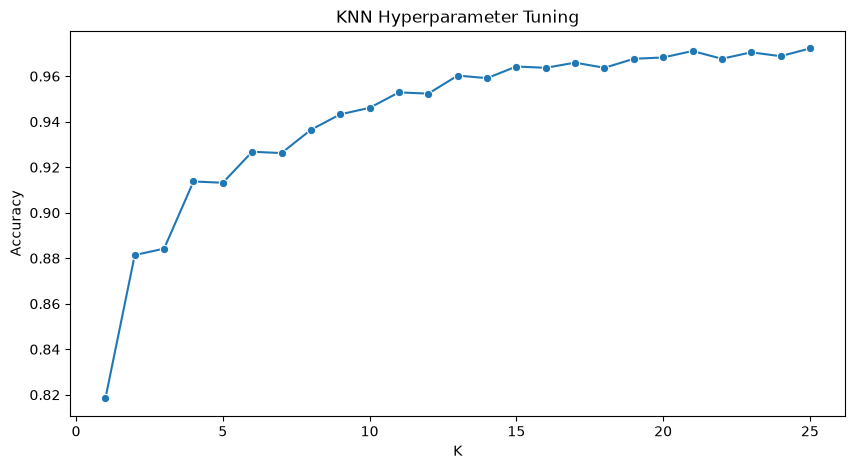

In [83]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=k_df, x="K", y="Accuracy", marker="o")
plt.title("KNN Hyperparameter Tuning")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [84]:
best_k = int(k_df.sort_values(by="Accuracy", ascending=False).iloc[0]["K"])

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_tfidf, y_train)
knn_pred = knn_final.predict(X_test_tfidf)
knn_acc = accuracy_score(y_test, knn_pred)

print("Best K:", best_k)
print("KNN Accuracy:", knn_acc)
print(classification_report(y_test, knn_pred))

Best K: 25
KNN Accuracy: 0.9721906923950057
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1227
           1       0.98      0.93      0.95       535

    accuracy                           0.97      1762
   macro avg       0.98      0.96      0.97      1762
weighted avg       0.97      0.97      0.97      1762



# Model Comparison

Now we compare all models in one table.

In [85]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Tuned Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        baseline_acc,
        lr_acc,
        nb_acc,
        dt_acc,
        dt_best_acc,
        knn_acc
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)
results

,Model,Accuracy
4,Tuned Decision Tree,0.996027
3,Decision Tree,0.991487
1,Logistic Regression,0.990352
5,KNN,0.972191
2,Naive Bayes,0.963678
0,Baseline,0.696368


C:\Users\acer\AppData\Local\Temp\ipykernel_7200\600649995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Accuracy", y="Model", palette="Reds_r")


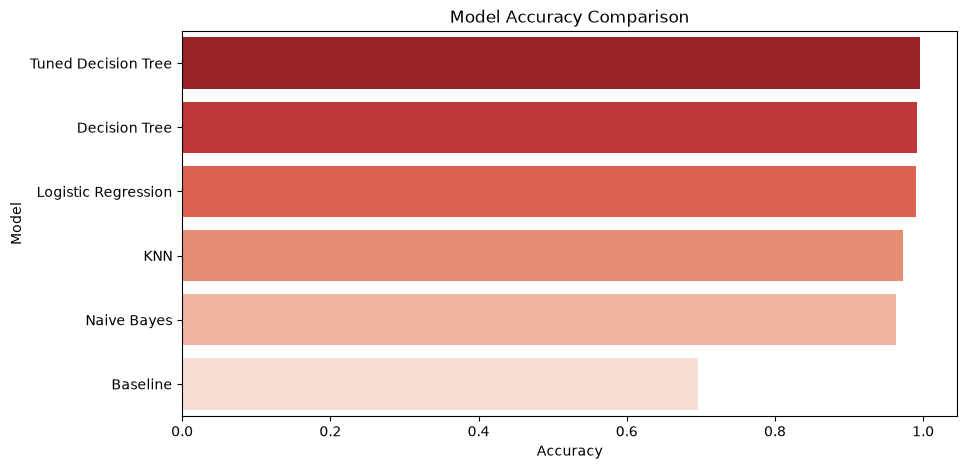

In [86]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Accuracy", y="Model", palette="Reds_r")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

In [87]:
import joblib

joblib.dump(
    baseline,
    "../models/1.Baseline_Model/baseline.pkl"
)

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [88]:
joblib.dump(
    lr,
    "../models/2.Logistic_Regression_Model/logistic.pkl"
)

joblib.dump(
    nb,
    "../models/3.Naive_Bayes_Model/naive_bayes.pkl"
)

joblib.dump(
    dt,
    "../models/4.Decision_Tree_Model/decision_tree.pkl"
)

joblib.dump(
    knn,
    "../models/5.KNN_Model/knn.pkl"
)

print("All models saved successfully!")

All models saved successfully!


# Conclusion

In this notebook, we trained and evaluated multiple machine learning models for Netflix content classification.

### Models Evaluated

- Baseline Model
- Logistic Regression
- Naive Bayes
- Decision Tree
- K-Nearest Neighbors (KNN)

Hyperparameter tuning was applied to optimize the Decision Tree model, and the performance of all models was compared using multiple evaluation metrics.

The trained models were saved for use in the recommendation system and Streamlit application.